In [4]:
import pandas as pd

# Load Excel files
firm_data = pd.read_excel("/content/Firm_data (1).xlsx")
targets_data = pd.read_excel("/content/Targets (1).xlsx")
print(firm_data.head())
print(targets_data.head())

    DATADATE  FYEAR STATE       AT              CONM     SALE  sic4  fin_d  \
0 2012-12-31   2012    TN   53.598  AAC HOLDINGS INC   66.035  8060      0   
1 2013-12-31   2013    TN   81.638  AAC HOLDINGS INC  115.741  8060      0   
2 2014-12-31   2014    TN  145.952  AAC HOLDINGS INC  132.968  8060      0   
3 2015-12-31   2015    TN  316.049  AAC HOLDINGS INC  212.261  8060      0   
4 2016-12-31   2016    TN  383.884  AAC HOLDINGS INC  279.770  8060      0   

   util_d  div_at  ...        MB       ROA  profit_margin  loss_d   debt_at  \
0       0     0.0  ...  0.983649  0.028061       0.072265       0  0.470577   
1       0     0.0  ...  0.958561  0.009628       0.085925       0  0.527634   
2       0     0.0  ...  4.860242  0.051716       0.134393       0  0.196236   
3       0     0.0  ...  1.927644  0.033201       0.131183       0  0.459236   
4       0     0.0  ...  1.016395 -0.001534       0.075180       1  0.492612   

    cash_at  rd_at  capex_at   nppe_at  cusip6  
0  0.01

# New Section

In [5]:
# Removing the  duplicates
firm_data = firm_data.drop_duplicates()
targets_data = targets_data.drop_duplicates()


In [6]:
# Converting announcement date to datetime
targets_data["ann_date"] = pd.to_datetime(targets_data["ann_date"], errors="coerce")

# Creating fiscal year = year of announcement - 1
targets_data["FYEAR"] = targets_data["ann_date"].dt.year - 1


In [7]:
# Ensuring that cusip6 format matches in both the datasets
firm_data["cusip6"] = firm_data["cusip6"].astype(str).str.upper()
targets_data["cusip6"] = targets_data["cusip6"].astype(str).str.upper()

# created `target' variable that equals 1
targets_data["target"] = 1

# Merging by 'cusip6' and 'FYEAR'
merged_data = pd.merge(firm_data, targets_data[["cusip6", "FYEAR", "target"]],
                       on=["cusip6", "FYEAR"], how="left")
print(merged_data.head())

# If not 1 non - targets will be 0
merged_data["target"] = merged_data["target"].fillna(0).astype(int)
print(merged_data.head())


    DATADATE  FYEAR STATE       AT              CONM     SALE  sic4  fin_d  \
0 2012-12-31   2012    TN   53.598  AAC HOLDINGS INC   66.035  8060      0   
1 2013-12-31   2013    TN   81.638  AAC HOLDINGS INC  115.741  8060      0   
2 2014-12-31   2014    TN  145.952  AAC HOLDINGS INC  132.968  8060      0   
3 2015-12-31   2015    TN  316.049  AAC HOLDINGS INC  212.261  8060      0   
4 2016-12-31   2016    TN  383.884  AAC HOLDINGS INC  279.770  8060      0   

   util_d  div_at  ...       ROA  profit_margin  loss_d   debt_at   cash_at  \
0       0     0.0  ...  0.028061       0.072265       0  0.470577  0.013806   
1       0     0.0  ...  0.009628       0.085925       0  0.527634  0.024645   
2       0     0.0  ...  0.051716       0.134393       0  0.196236  0.332575   
3       0     0.0  ...  0.033201       0.131183       0  0.459236  0.059326   
4       0     0.0  ... -0.001534       0.075180       1  0.492612  0.010326   

   rd_at  capex_at   nppe_at  cusip6  target  
0    0.0 

In [8]:
# Getting the first digit of SIC4 code
merged_data["sic1"] = merged_data["sic4"] // 1000
print(merged_data.head())

    DATADATE  FYEAR STATE       AT              CONM     SALE  sic4  fin_d  \
0 2012-12-31   2012    TN   53.598  AAC HOLDINGS INC   66.035  8060      0   
1 2013-12-31   2013    TN   81.638  AAC HOLDINGS INC  115.741  8060      0   
2 2014-12-31   2014    TN  145.952  AAC HOLDINGS INC  132.968  8060      0   
3 2015-12-31   2015    TN  316.049  AAC HOLDINGS INC  212.261  8060      0   
4 2016-12-31   2016    TN  383.884  AAC HOLDINGS INC  279.770  8060      0   

   util_d  div_at  ...  profit_margin  loss_d   debt_at   cash_at  rd_at  \
0       0     0.0  ...       0.072265       0  0.470577  0.013806    0.0   
1       0     0.0  ...       0.085925       0  0.527634  0.024645    0.0   
2       0     0.0  ...       0.134393       0  0.196236  0.332575    0.0   
3       0     0.0  ...       0.131183       0  0.459236  0.059326    0.0   
4       0     0.0  ...       0.075180       1  0.492612  0.010326    0.0   

   capex_at   nppe_at  cusip6  target  sic1  
0  0.116870  0.285962  00030

In [9]:
import pandas as pd

# Load datasets
firm_data = pd.read_excel("Firm_data (1).xlsx")
targets_data = pd.read_excel("Targets (1).xlsx")

# Step 1: Remove duplicates
firm_data = firm_data.drop_duplicates()
targets_data = targets_data.drop_duplicates()

# Step 2: Create FYEAR from announcement date in targets data
targets_data["ann_date"] = pd.to_datetime(targets_data["ann_date"], errors="coerce")
targets_data["FYEAR"] = targets_data["ann_date"].dt.year - 1

# Step 3: Standardize CUSIP to match format
firm_data["cusip6"] = firm_data["cusip6"].astype(str).str.upper()
targets_data["cusip6"] = targets_data["cusip6"].astype(str).str.upper()

# Step 4: Add target label
targets_data["target"] = 1

# Step 5: Merge on cusip6 and FYEAR
merged_data = pd.merge(firm_data, targets_data[["cusip6", "FYEAR", "target"]],
                       on=["cusip6", "FYEAR"], how="left")
merged_data["target"] = merged_data["target"].fillna(0).astype(int)

# Step 6: Create sic1 (first digit of sic4)
merged_data["sic1"] = merged_data["sic4"] // 1000

# Removing duplicates (just in case)
cleaned_data = merged_data.drop_duplicates()

# Dropping rows with any missing values
cleaned_data = cleaned_data.dropna()

# Remove outliers using IQR method
def remove_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

numeric_cols = cleaned_data.select_dtypes(include=["float64", "int64"]).columns
final_data = remove_outliers_iqr(cleaned_data, numeric_cols)

# Save to Excel
final_data.to_excel("Cleaned_Firm_Data.xlsx", index=False)
print(final_data.head())

     DATADATE  FYEAR STATE       AT              CONM     SALE  sic4  fin_d  \
4  2016-12-31   2016    TN  383.884  AAC HOLDINGS INC  279.770  8060      0   
5  2017-12-31   2017    TN  428.275  AAC HOLDINGS INC  317.641  8060      0   
6  2018-12-31   2018    TN  452.277  AAC HOLDINGS INC  301.763  8060      0   
12 1996-12-31   1996    OK   35.569          AAON INC   62.845  3585      0   
14 1998-12-31   1998    OK   50.506          AAON INC  106.781  3585      0   

    util_d  div_at  ...  profit_margin  loss_d   debt_at   cash_at  rd_at  \
4        0     0.0  ...       0.075180       1  0.492612  0.010326    0.0   
5        0     0.0  ...       0.121300       1  0.527217  0.032264    0.0   
6        0     0.0  ...       0.009799       1  0.759933  0.011959    0.0   
12       0     0.0  ...       0.113486       0  0.254913  0.003880    0.0   
14       0     0.0  ...       0.112857       0  0.232388  0.000495    0.0   

    capex_at   nppe_at  cusip6  target  sic1  
4   0.097175  0

Part 2

> Add blockquote

> Add blockquote





In [10]:
from google.colab import files
uploaded = files.upload()

Saving Cleaned_Firm_Data.xlsx to Cleaned_Firm_Data (1).xlsx


In [ ]:
list(uploaded.keys())


['Firm_data (1) (1).xlsx']

In [ ]:
!pip install rapidfuzz


Refurbished model 1 and model 2

In [11]:
# Model 1 & Model 2

import pandas as pd, numpy as np, re, glob, statsmodels.api as sm

# ---------- 1) File detection ----------
firm_candidates = [
    "Firm_data (1) (1).xlsx", "Firm_data (1).xlsx", "Cleaned_Firm_Data.xlsx", "Firm_data.xlsx"
]
tgt_candidates = [
    "Targets (1) (1).xlsx", "Targets (1).xlsx", "Targets.xlsx"
]
def pick_file(cands):
    for c in cands:
        if c in set(glob.glob("*")):
            return c
    raise FileNotFoundError(f"None of {cands} found.")
FIRM_PATH = pick_file(firm_candidates)
TARGETS_PATH = pick_file(tgt_candidates)
print("Using files ->", FIRM_PATH, "|", TARGETS_PATH)

# ---------- 2) Helpers ----------
def z6(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().upper()
    s = re.sub(r'[^A-Z0-9]', '', s)
    if s.isdigit(): s = s.zfill(6)
    return s[:6]

def winsorize(s, p=0.01):
    s = pd.to_numeric(s, errors="coerce")
    return s.clip(s.quantile(p), s.quantile(1-p))

def make_design_numeric(df, cols):
    X = df[cols].copy()
    for c in X.columns: X[c] = pd.to_numeric(X[c], errors="coerce")
    return X.replace([np.inf,-np.inf], np.nan).astype(float)

def fit_logit(df, features, ycol="target", label=""):
    X = make_design_numeric(df, features)
    y = pd.to_numeric(df[ycol], errors="coerce")
    ok = pd.concat([X, y.rename("__y__")], axis=1).dropna()
    print(f"   -> [{label}] rows used: {len(ok)}")
    X_ok = sm.add_constant(ok[features], has_constant="add")
    y_ok = ok["__y__"].astype(int)
    res = sm.Logit(y_ok, X_ok).fit(disp=False, maxiter=400)
    return res

# ---------- 3) Load + light clean ----------
firm = pd.read_excel(FIRM_PATH)
tgt  = pd.read_excel(TARGETS_PATH)

firm.columns = firm.columns.str.strip()
tgt.columns  = tgt.columns.str.strip()

# Year
if "fyear" in firm.columns:
    firm["fyear"] = pd.to_numeric(firm["fyear"], errors="coerce").astype("Int64")
elif "FYEAR" in firm.columns:
    firm = firm.rename(columns={"FYEAR":"fyear"})
    firm["fyear"] = pd.to_numeric(firm["fyear"], errors="coerce").astype("Int64")
else:
    raise ValueError("Firm_data must contain FYEAR/fyear.")

if "fyear" in tgt.columns:
    tgt["fyear"] = pd.to_numeric(tgt["fyear"], errors="coerce").astype("Int64")
else:
    if "ann_date" not in tgt.columns:
        raise ValueError("Targets must contain fyear or ann_date.")
    tgt["fyear"] = (pd.to_datetime(tgt["ann_date"], errors="coerce").dt.year - 1).astype("Int64")
    print("Derived 'fyear' in targets from ann_date - 1 (assignment requirement).")

# Target flag
if "target" not in tgt.columns:
    tgt["target"] = 1

# Merge key
if "cusip6" not in firm.columns or "cusip6" not in tgt.columns:
    raise ValueError("Both files must include 'cusip6'.")
firm["cusip6_norm"] = firm["cusip6"].apply(z6)
tgt["cusip6_norm"]  = tgt["cusip6"].apply(z6)

firm = firm.dropna(subset=["cusip6_norm","fyear"]).copy()
tgt  = tgt.dropna(subset=["cusip6_norm","fyear"]).copy()

# Leverage alias
if "leverage" not in firm.columns and "debt_at" in firm.columns:
    firm["leverage"] = firm["debt_at"]

# Merge
df = pd.merge(
    firm,
    tgt[["cusip6_norm","fyear","target"]].drop_duplicates(),
    on=["cusip6_norm","fyear"], how="left"
)
df["target"] = df["target"].fillna(0).astype(int)

print("Merged rows:", len(df), "| targets=1:", int(df["target"].sum()))

# ---------- 4) Features & transforms ----------
# Controls you likely have
controls_raw = [c for c in ["ret","leverage","sale_gr","cash_at","rd_at"] if c in df.columns]
controls_w   = []
for c in ["ret","leverage","sale_gr","cash_at","rd_at"]:
    if c in df.columns:
        df[c+"_w"] = winsorize(df[c], p=0.01)
        controls_w.append(c+"_w")

# Logs
if "AT" in df.columns:
    df["log_AT"] = np.log(pd.to_numeric(df["AT"], errors="coerce").clip(lower=0) + 1)

# ---------- 5) Model 1: AT + raw controls ----------
if "AT" not in df.columns:
    raise ValueError("Model 1 expects 'AT' (total assets).")
M1 = ["AT"] + controls_raw
print("\n--- Model 1: target ~ AT + raw controls ---")
print("Features:", M1)
res1 = fit_logit(df, M1, ycol="target", label="Model 1")
print(res1.summary())

# ---------- 6) Model 2: log_AT + winsorized controls ----------
if "log_AT" not in df.columns:
    raise ValueError("Model 2 expects 'log_AT'.")
M2 = ["log_AT"] + controls_w
print("\n--- Model 2: target ~ log_AT + winsorized controls ---")
print("Features:", M2)
res2 = fit_logit(df, M2, ycol="target", label="Model 2")
print(res2.summary())

Using files -> Firm_data (1).xlsx | Targets (1).xlsx
Derived 'fyear' in targets from ann_date - 1 (assignment requirement).
Merged rows: 159032 | targets=1: 2356

--- Model 1: target ~ AT + raw controls ---
Features: ['AT', 'ret', 'leverage', 'sale_gr', 'cash_at', 'rd_at']
   -> [Model 1] rows used: 136184


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


                           Logit Regression Results                           
Dep. Variable:                  __y__   No. Observations:               136184
Model:                          Logit   Df Residuals:                   136177
Method:                           MLE   Df Model:                            6
Date:                Mon, 01 Sep 2025   Pseudo R-squ.:                0.002851
Time:                        09:40:21   Log-Likelihood:                -11288.
converged:                       True   LL-Null:                       -11320.
Covariance Type:            nonrobust   LLR p-value:                 5.330e-12
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.2187      0.043    -99.099      0.000      -4.302      -4.135
AT         -5.264e-06   1.53e-06     -3.443      0.001   -8.26e-06   -2.27e-06
ret           -0.0826      0.028     -2.996      0.0

Refurbished model 3

In [ ]:
# ============================================
# MODEL 3 (with FE) — hardened against object dtype + singularities
# ============================================

import pandas as pd, numpy as np, re, glob, statsmodels.api as sm

# -------- 0) Re-load minimal pieces (safe if already loaded) --------
firm_candidates = ["Firm_data (1) (1).xlsx","Firm_data (1).xlsx","Cleaned_Firm_Data.xlsx","Firm_data.xlsx"]
tgt_candidates  = ["Targets (1) (1).xlsx","Targets (1).xlsx","Targets.xlsx"]
def pick_file(cands):
    for c in cands:
        if c in set(glob.glob("*")):
            return c
    raise FileNotFoundError(f"None of {cands} found.")
FIRM_PATH = pick_file(firm_candidates)
TARGETS_PATH = pick_file(tgt_candidates)
print("Using files ->", FIRM_PATH, "|", TARGETS_PATH)

def z6(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().upper()
    s = re.sub(r'[^A-Z0-9]', '', s)
    if s.isdigit(): s = s.zfill(6)
    return s[:6]

def winsorize(s, p=0.01):
    s = pd.to_numeric(s, errors="coerce")
    lo, hi = s.quantile(p), s.quantile(1-p)
    return s.clip(lo, hi)

firm = pd.read_excel(FIRM_PATH)
tgt  = pd.read_excel(TARGETS_PATH)
firm.columns = firm.columns.str.strip()
tgt.columns  = tgt.columns.str.strip()

# Year normalization
if "fyear" in firm.columns:
    firm["fyear"] = pd.to_numeric(firm["fyear"], errors="coerce").astype("Int64")
elif "FYEAR" in firm.columns:
    firm = firm.rename(columns={"FYEAR":"fyear"})
    firm["fyear"] = pd.to_numeric(firm["fyear"], errors="coerce").astype("Int64")
else:
    raise ValueError("Firm_data must contain FYEAR/fyear.")
if "fyear" in tgt.columns:
    tgt["fyear"] = pd.to_numeric(tgt["fyear"], errors="coerce").astype("Int64")
else:
    tgt["fyear"] = (pd.to_datetime(tgt["ann_date"], errors="coerce").dt.year - 1).astype("Int64")
print("Derived 'fyear' in targets from ann_date - 1 (assignment requirement).")

# Target flag
if "target" not in tgt.columns:
    tgt["target"] = 1

# Merge key
if "cusip6" not in firm.columns or "cusip6" not in tgt.columns:
    raise ValueError("Both files must include 'cusip6'.")
firm["cusip6_norm"] = firm["cusip6"].apply(z6)
tgt["cusip6_norm"]  = tgt["cusip6"].apply(z6)

firm = firm.dropna(subset=["cusip6_norm","fyear"]).copy()
tgt  = tgt.dropna(subset=["cusip6_norm","fyear"]).copy()

# Industry (sic1) if missing
if "sic1" not in firm.columns:
    if "sic4" in firm.columns:
        firm["sic1"] = (pd.to_numeric(firm["sic4"], errors="coerce") // 1000).astype("Int64")
    else:
        firm["sic1"] = pd.NA

# State alias
if "state" not in firm.columns and "STATE" in firm.columns:
    firm = firm.rename(columns={"STATE":"state"})

# Leverage alias
if "leverage" not in firm.columns and "debt_at" in firm.columns:
    firm["leverage"] = firm["debt_at"]

# Merge on (cusip6_norm, fyear)
df = pd.merge(
    firm,
    tgt[["cusip6_norm","fyear","target"]].drop_duplicates(),
    on=["cusip6_norm","fyear"], how="left"
)
df["target"] = df["target"].fillna(0).astype(int)
print("Merged rows:", len(df), "| targets=1:", int(df["target"].sum()))

# -------- 1) Build Model 3 features (strict numeric) --------
# Winsorized controls (ensure float)
controls_w = []
for c in ["ret","leverage","sale_gr","cash_at","rd_at"]:
    if c in df.columns:
        w = winsorize(df[c], p=0.01).astype(float)
        df[c+"_w"] = w
        controls_w.append(c+"_w")

# log_SALE
if "SALE" not in df.columns:
    raise ValueError("Model 3 expects 'SALE' column.")
df["log_SALE"] = np.log(pd.to_numeric(df["SALE"], errors="coerce").clip(lower=0) + 1).astype(float)

# FE dummies — force dtype float to avoid object
fe_ind = (pd.get_dummies(df["sic1"].astype("category"), prefix="sic1", drop_first=True, dtype=float)
          if "sic1" in df.columns else pd.DataFrame(index=df.index, dtype=float))
fe_yr  = pd.get_dummies(df["fyear"].astype("category"), prefix="yr", drop_first=True, dtype=float)

# Combine and collect feature names
df_fe  = pd.concat([df, fe_ind, fe_yr], axis=1)
FE_COLS = list(fe_ind.columns) + list(fe_yr.columns)
M3 = ["log_SALE"] + controls_w + FE_COLS
print("Model 3 feature count:", len(M3))

# -------- 2) Scale continuous vars (z-score) so exp() stays stable --------
cont_cols = ["log_SALE"] + controls_w
df_scaled = df_fe.copy()
for c in cont_cols:
    x = pd.to_numeric(df_scaled[c], errors="coerce")
    mu = float(np.nanmean(x))
    sd = float(np.nanstd(x))
    if not np.isfinite(sd) or sd == 0.0:
        df_scaled[c] = 0.0
    else:
        df_scaled[c] = (x - mu) / sd
# Ensure FE columns are float (already set via dtype=float above)
for c in FE_COLS:
    df_scaled[c] = pd.to_numeric(df_scaled[c], errors="coerce").astype(float)

# -------- 3) Build clean X,y and convert to NumPy float arrays --------
X = df_scaled[M3].copy()
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")
# drop zero-variance columns to avoid singularities
nunq = X.nunique(dropna=False)
drop_0var = nunq[nunq <= 1].index.tolist()
if drop_0var:
    print(f"   -> Dropping {len(drop_0var)} zero-variance columns.")
    X = X.drop(columns=drop_0var)

# add constant
X = sm.add_constant(X, has_constant="add")

# y vector
y = pd.to_numeric(df_scaled["target"], errors="coerce").astype(float)

# align and drop any non-finite rows
XY = pd.concat([X, y.rename("__y__")], axis=1)
XY = XY.replace([np.inf, -np.inf], np.nan).dropna()
X_num = XY.drop(columns="__y__").astype(float).to_numpy()
y_num = XY["__y__"].astype(float).to_numpy()
print(f"Rows used: {X_num.shape[0]}, Features (incl const): {X_num.shape[1]}")

# -------- 4) Fit ridge-regularized Logit with NUMPY arrays --------
# If needed, change alpha to 2.0 or 0.5
model = sm.Logit(y_num, X_num)
res3 = model.fit_regularized(alpha=1.0, L1_wt=0.0, disp=False, maxiter=1000)
print(res3.summary())

# -------- 5) Quick interpretability --------
# names for non-FE terms (we dropped some zero-var possibly; map surviving indices)
kept_cols = XY.drop(columns="__y__").columns.tolist()
coef_series = pd.Series(res3.params, index=kept_cols)

nonfe = [c for c in ["const","log_SALE"] + controls_w if c in coef_series.index]
print("\nTop (absolute) coefficients among non-FE terms:")
coefs = coef_series[nonfe].dropna()
print(coefs.reindex(coefs.abs().sort_values(ascending=False).index))

yr_mask = coef_series.index.str.startswith("yr_")
if yr_mask.any():
    print("\nTop 10 Year FE (higher ⇒ more likely):")
    print(coef_series[yr_mask].sort_values(ascending=False).head(10))
else:
    print("\n(No year FE retained after cleaning.)")


Using files -> Firm_data (1) (1).xlsx | Targets (1).xlsx
Derived 'fyear' in targets from ann_date - 1 (assignment requirement).
Merged rows: 159032 | targets=1: 2356
Model 3 feature count: 44
Rows used: 136184, Features (incl const): 45
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               136184
Model:                          Logit   Df Residuals:                   136141
Method:                           MLE   Df Model:                           42
Date:                Sun, 31 Aug 2025   Pseudo R-squ.:                  0.1717
Time:                        07:31:53   Log-Likelihood:                -9376.8
converged:                       True   LL-Null:                       -11320.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

Descriptive statistics of main variables

In [12]:
# === STEP 1: Descriptive statistics for key variables ===
import pandas as pd
import numpy as np

# Pick main variables available in your dataset
main_vars = [v for v in [
    'AT','SALE','ROA','profit_margin','ret','sale_gr','assets_gr','MB',
    'cash_at','debt_at','rd_at','capex_at','nppe_at','target'
] if v in df.columns]

# Build summary table
desc = df[main_vars].describe(percentiles=[0.25, 0.5, 0.75]).T
desc['missing_pct'] = df[main_vars].isna().mean() * 100
desc['n'] = df[main_vars].notna().sum()
desc = desc.rename(columns={
    'count':'Count','mean':'Mean','std':'Std','min':'Min','25%':'P25','50%':'Median','75%':'P75','max':'Max'
})[['Count','n','Mean','Std','Min','P25','Median','P75','Max','missing_pct']]

print("Descriptive statistics (key variables):")
print(desc.round(4))


Descriptive statistics (key variables):
                  Count       n       Mean         Std         Min      P25  \
AT             159032.0  159032  6515.1217  60554.1874      0.0010  55.7035   
SALE           158909.0  158909  2315.7326  13038.5063  -4234.4720  25.1820   
ROA            158919.0  158919    -0.1714     26.4200 -10311.6364  -0.0553   
profit_margin  148028.0  148028    -5.4093    165.2736 -29325.7000   0.0207   
ret            141435.0  141435     1.2412    205.8066     -1.0000  -0.2503   
sale_gr        136718.0  136718     1.2740    110.5537   -237.0000  -0.0349   
assets_gr      141445.0  141445     1.5183    399.7622     -0.9998  -0.0408   
MB             159032.0  159032    10.3448   1061.7464     -0.9949   1.0271   
cash_at        159016.0  159016     0.2015      0.2488     -0.8256   0.0278   
debt_at        158434.0  158434     0.2086      0.2052     -0.0500   0.0235   
rd_at          159032.0  159032     0.0576      0.5125     -0.0638   0.0000   
capex_at    

Correlation Analysis

Correlation Matrix:
            AT    ret  sale_gr  cash_at  debt_at  rd_at    ROA
AT       1.000 -0.000   -0.001   -0.032    0.033 -0.032  0.003
ret     -0.000  1.000   -0.000   -0.002    0.003 -0.002  0.000
sale_gr -0.001 -0.000    1.000    0.005    0.003  0.002 -0.000
cash_at -0.032 -0.002    0.005    1.000   -0.363  0.443 -0.008
debt_at  0.033  0.003    0.003   -0.363    1.000 -0.162  0.003
rd_at   -0.032 -0.002    0.002    0.443   -0.162  1.000 -0.063
ROA      0.003  0.000   -0.000   -0.008    0.003 -0.063  1.000


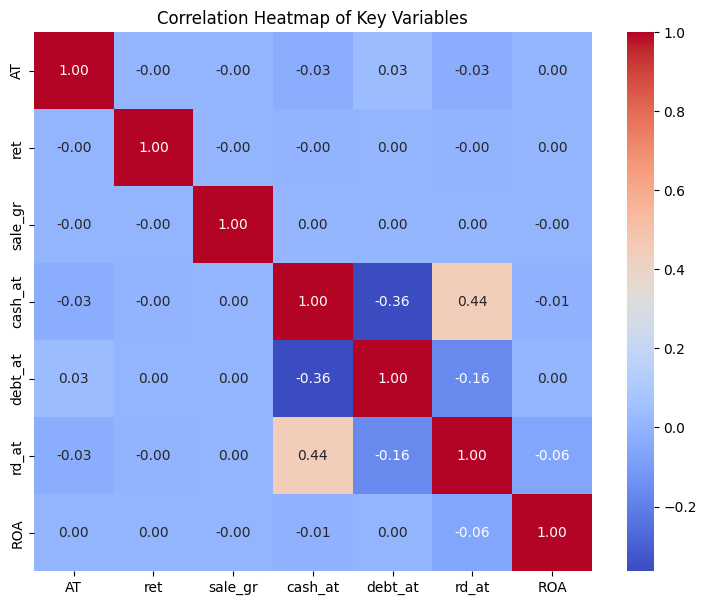

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select main variables to check correlation
corr_vars =  corr_vars = ["AT", "ret", "sale_gr", "cash_at", "debt_at", "rd_at", "ROA"]
# Drop missing values
corr_data = df[corr_vars].dropna()

# 1) Correlation Matrix (Table)
corr_matrix = corr_data.corr()
print("Correlation Matrix:")
print(corr_matrix.round(3))

# Save to Excel for report
corr_matrix.round(3).to_excel("Task2_Correlation_Matrix.xlsx")

# 2) Correlation Heatmap (Visualization)
plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of Key Variables")
plt.show()

Year with highest M&A target rate

In [ ]:
# Year with highest M&A target rate

# Making sure fyear is numeric
df['fyear'] = pd.to_numeric(df['fyear'], errors='coerce')

# Group by year: proportion of targets, targets, and total obervations
g = df.groupby('fyear')['target']
year_rate = pd.DataFrame({
    'target_rate': g.mean(),
    'targets': g.sum(),
    'n': g.size()
}).sort_values('target_rate', ascending=False)

print("Top years by target rate:")
print(year_rate.head(10).round(4))

# Extract most likely year
best_year = int(year_rate.index[0])
best_rate = float(year_rate.iloc[0]['target_rate'])
print(f"\nMost likely year to be a target: {best_year} (rate = {best_rate:.2%})")

Top years by target rate:
       target_rate  targets     n
fyear                            
2009        0.0430      203  4726
2015        0.0428      191  4465
2014        0.0406      189  4654
2011        0.0399      183  4589
2016        0.0373      159  4267
2018        0.0367      153  4168
2020        0.0367      152  4147
2017        0.0364      153  4209
2010        0.0348      163  4679
2013        0.0344      158  4587

Most likely year to be a target: 2009 (rate = 4.30%)


Are unprofitable California firms more likely to be targets?

Predict probability for a given firm (2015)

In [ ]:
# Predict probability for given firm (2015) ===

# Build a one-row DataFrame with the firm’s characteristics
firm_2015 = pd.DataFrame([{
    'SALE': 500,
    'ret': 0.2,
    'leverage': 0.1,
    'sale_gr': 0.15,
    'cash_at': 0.2,
    'rd_at': 0.1,
    'state': "California",
    'sic1': 2,
    'fyear': 2015
}])

# Apply the same transformations as in Model 3
firm_2015['log_SALE'] = np.log(firm_2015['SALE'] + 1)
firm_2015['ret_w'] = firm_2015['ret']
firm_2015['leverage_w'] = firm_2015['leverage']
firm_2015['sale_gr_w'] = firm_2015['sale_gr']
firm_2015['cash_at_w'] = firm_2015['cash_at']
firm_2015['rd_at_w'] = firm_2015['rd_at']

# Add FE dummies for sic1 and fyear
fe_ind = pd.get_dummies(df['sic1'].astype("category"), prefix="sic1", drop_first=True, dtype=float)
fe_yr  = pd.get_dummies(df['fyear'].astype("category"), prefix="yr", drop_first=True, dtype=float)

# Match columns with training model
firm_fe = pd.get_dummies(firm_2015['sic1'].astype("category"), prefix="sic1", drop_first=True, dtype=float).reindex(columns=fe_ind.columns, fill_value=0)
firm_yr = pd.get_dummies(firm_2015['fyear'].astype("category"), prefix="yr", drop_first=True, dtype=float).reindex(columns=fe_yr.columns, fill_value=0)

firm_final = pd.concat([firm_2015, firm_fe, firm_yr], axis=1)

# Keep same features as in Model 3
X_new = firm_final.reindex(columns=X.columns, fill_value=0)

# Predict probability
prob = res3.predict(X_new)[0]
print(f"Predicted probability of becoming an M&A target in 2015: {prob:.4f}")

Predicted probability of becoming an M&A target in 2015: 0.5058


Train 2010–2023, Predict 2024

In [ ]:
# === STEP 5: Train on 2010–2023, Predict 2024 (robust to NaNs/∞) ===

# 1) Filter training (2010–2023) and test (2024)
train_df = df[(df['fyear'] >= 2010) & (df['fyear'] <= 2023)].copy()
test_df  = df[df['fyear'] == 2024].copy()

# 2) Features like Model 3
controls = ["ret","leverage","sale_gr","cash_at","rd_at"]
controls_w = []
for c in controls:
    if c in train_df.columns:
        # numeric coercion (winsorization optional here)
        train_df[c+"_w"] = pd.to_numeric(train_df[c], errors="coerce")
        test_df[c+"_w"]  = pd.to_numeric(test_df[c],  errors="coerce")
        controls_w.append(c+"_w")

# log_SALE
train_df["log_SALE"] = np.log(pd.to_numeric(train_df["SALE"], errors="coerce").clip(lower=0) + 1)
test_df["log_SALE"]  = np.log(pd.to_numeric(test_df["SALE"],  errors="coerce").clip(lower=0) + 1)

# 3) Fixed effects (industry & year)
fe_ind_train = pd.get_dummies(train_df["sic1"].astype("category"), prefix="sic1", drop_first=True, dtype=float)
fe_yr_train  = pd.get_dummies(train_df["fyear"].astype("category"), prefix="yr",   drop_first=True, dtype=float)
train_fe     = pd.concat([train_df, fe_ind_train, fe_yr_train], axis=1)

fe_ind_test = pd.get_dummies(test_df["sic1"].astype("category"),  prefix="sic1", drop_first=True, dtype=float).reindex(columns=fe_ind_train.columns, fill_value=0)
fe_yr_test  = pd.get_dummies(test_df["fyear"].astype("category"), prefix="yr",   drop_first=True, dtype=float).reindex(columns=fe_yr_train.columns,  fill_value=0)
test_fe     = pd.concat([test_df, fe_ind_test, fe_yr_test], axis=1)

FE_COLS = list(fe_ind_train.columns) + list(fe_yr_train.columns)
M3 = ["log_SALE"] + controls_w + FE_COLS

# 4) Build clean training matrix (coerce → scrub → dropna)
X_train = train_fe[M3].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
y_train = pd.to_numeric(train_fe["target"], errors="coerce")

XY = pd.concat([X_train, y_train.rename("__y__")], axis=1).dropna()
X_train = XY.drop(columns="__y__")
y_train = XY["__y__"].astype(int)

# Add constant
X_train = sm.add_constant(X_train, has_constant="add")

# 5) Fit logit
res_train = sm.Logit(y_train, X_train).fit(disp=False, maxiter=500)

# 6) Prepare test matrix; fill NaNs with training medians (cont) and 0 for FE
X_test = test_fe[M3].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

# Split columns: continuous vs FE
cont_cols = ["log_SALE"] + controls_w
fe_cols   = FE_COLS

train_medians = XY[cont_cols].median(numeric_only=True)
X_test[cont_cols] = X_test[cont_cols].fillna(train_medians)
X_test[fe_cols]   = X_test[fe_cols].fillna(0)

X_test = sm.add_constant(X_test, has_constant="add")

# 7) Predict on 2024
test_df["pred_prob"] = res_train.predict(X_test)

# 8) Top 10 + hits
top10 = test_df.sort_values("pred_prob", ascending=False).head(10)
print("Top 10 predicted M&A targets for 2024:")
print(top10[["CONM","pred_prob","target"]].round(4))

hits = top10[(top10["pred_prob"] > 0.5) & (top10["target"] == 1)]
print("\nCorrectly identified actual targets in 2024:")
print(hits[["CONM","pred_prob"]].round(4))

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


Top 10 predicted M&A targets for 2024:
                                CONM  pred_prob  target
68461                  HEARTBEAM INC     0.0796       0
62422                GEOVAX LABS INC     0.0747       0
65174         GREENWICH LIFESCIE INC     0.0734       0
62041                    GENPREX INC     0.0731       0
97591                  CLARITEV CORP     0.0708       0
14771        AVENUE THERAPEUTICS INC     0.0702       0
121272                 REGIS CORP/MN     0.0700       0
158752              ZIPRECRUITER INC     0.0697       0
30696                      CHEGG INC     0.0683       0
116706  PROCESSA PHARMACEUTICALS INC     0.0681       0

Correctly identified actual targets in 2024:
Empty DataFrame
Columns: [CONM, pred_prob]
Index: []


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


California + unprofitable (robust state mapping)

In [ ]:
#Robust California mapping + unprofitable check
# Start from df
s = df['state'].astype(str).str.strip()

# Normalize common California variants to 'CA'
ca_aliases = ['CA','CALIFORNIA','CALIF.','CALIF','CAL','CALI']
state_norm = s.str.upper()
state_norm = np.where(state_norm.isin(ca_aliases), 'CA', state_norm)
df['state_norm'] = state_norm

# Ensure loss_d numeric (1 = loss, 0 = profit)
df['loss_d'] = pd.to_numeric(df.get('loss_d'), errors='coerce')

# Subset to California
ca = df[df['state_norm'] == 'CA'].copy()

print(f"Rows with state mapped to CA: {len(ca)}")

# Target rates by profitability within California
ca_rates = ca.groupby('loss_d', dropna=False)['target'].mean().reset_index()
ca_rates.columns = ['loss_d (0=profit,1=loss,NaN=unknown)', 'target_rate']
print("\nCalifornia firms — target likelihood by profitability:")
print(ca_rates.round(4))

# For context: all states
overall = df.groupby('loss_d', dropna=False)['target'].mean().reset_index()
overall.columns = ['loss_d (0=profit,1=loss,NaN=unknown)', 'target_rate']
print("\nAll states — target likelihood by profitability:")
print(overall.round(4))

Rows with state mapped to CA: 23420

California firms — target likelihood by profitability:
   loss_d (0=profit,1=loss,NaN=unknown)  target_rate
0                                     0       0.0160
1                                     1       0.0202

All states — target likelihood by profitability:
   loss_d (0=profit,1=loss,NaN=unknown)  target_rate
0                                     0       0.0139
1                                     1       0.0164


Target Rate by Year